### Prosody-Controlled Speech Synthesis with FastPitch

Short Description:
This script generates human-like speech from text using a FastPitch neural TTS model, demonstrating explicit control over prosodic features (pitch, speed, emphasis). It highlights dynamic pitch adjustments through embedded text tags and global speech parameter tuning, optimized for GPU acceleration.

Key Libraries Used:

    TTS (Coqui-TTS): Text-to-speech engine for model loading/inference

    torch: Underlying deep learning framework (implicitly used by TTS)

Code Logic and Flow

High-Level Overview:
The workflow initializes a pre-trained FastPitch TTS model, processes input text containing embedded prosody tags (e.g., <LOW pitch>), synthesizes speech with customized pitch/speed/emphasis parameters, and exports the output as a WAV file. Global prosody settings are applied alongside localized tag-driven adjustments.

Visual Flow:

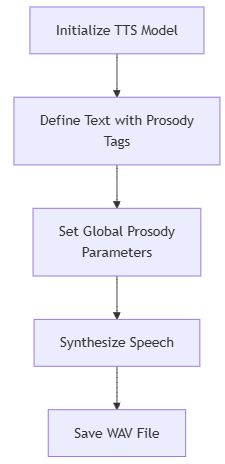

Step-by-Step Code Breakdown

Step 1: Model Initialization

    Loads the pre-trained FastPitch model trained on LJSpeech (English)

    Enables GPU acceleration and suppresses progress bars

    Prepares the model for inference with optimized settings

Step 2: Speech Synthesis Configuration

    Defines input text with embedded pitch/speed tags (<LOW pitch>, <HIGH speed>)

    Sets output filename (prosody_controlled.wav)

    Configures three key prosody parameters:

        pitch_scale: Global pitch shift (>1 = higher)

        speed_scale: Speaking rate (<1 = slower)

        emphasis: Stress intensity on syllables (>1 = stronger)

Step 3: Audio Generation, Playback & Export

    Synthesizes speech using mixed prosody controls:

        Processes embedded tags for dynamic pitch/speed shifts mid-utterance

        Applies global pitch/speed/emphasis scaling

    Uses FP16 precision and CUDA for accelerated inference

    Saves the generated audio to the specified WAV file

Connecting to the Lecture

This implementation directly applies lecture concepts on expressive speech synthesis and prosodic control in neural TTS systems. The embedded tags demonstrate how SpeechLMs enable fine-grained, context-aware prosody manipulation – a key advancement over traditional static TTS. The explicit parameter tuning (pitch_scale, speed_scale) reflects techniques to minimize error propagation in cascaded TTS architectures. Hardware optimizations (half=True, use_cuda=True) address real-world latency constraints discussed in deployment scenarios, while the FastPitch model exemplifies the industry shift toward non-autoregressive architectures for improved stability and efficiency.

In [6]:
# Install: pip install TTS==0.22.0 sounddevice soundfile numpy
from TTS.api import TTS
import torch
import numpy as np
import sounddevice as sd
import soundfile as sf
import tempfile
import os
import time

def detect_device():
    """Detect available compute device"""
    if torch.cuda.is_available():
        return True, "cuda"
    elif torch.backends.mps.is_available():
        return True, "mps"  
    else:
        return False, "cpu"

def play_audio_sd(file_path, volume=0.8):
    """Play audio using sounddevice with better error handling"""
    try:
        print(f"🔊 Loading audio file: {file_path}")
        
        # Load audio data
        data, sample_rate = sf.read(file_path)
        print(f"📊 Audio info: {data.shape} samples at {sample_rate} Hz")
        
        # Handle mono/stereo
        if len(data.shape) == 1:
            print("🎵 Mono audio detected")
        else:
            print(f"🎵 Audio has {data.shape[1]} channels")
        
        # Adjust volume
        data = data * volume
        
        # Play audio
        print("🔊 Playing audio... (Press Ctrl+C to stop)")
        sd.play(data, sample_rate)
        
        # Wait for playback to complete
        sd.wait()
        print("✅ Playback finished!")
        return True
        
    except Exception as e:
        print(f"❌ Error playing audio: {e}")
        print("Trying alternative playback method...")
        
        # Alternative: use OS-specific commands
        try:
            import subprocess
            import platform
            
            system = platform.system().lower()
            if system == "windows":
                subprocess.run(["start", file_path], shell=True, check=True)
            elif system == "darwin":  # macOS
                subprocess.run(["afplay", file_path], check=True)
            elif system == "linux":
                subprocess.run(["aplay", file_path], check=True)
            
            print("✅ Audio played using system player")
            return True
            
        except Exception as e2:
            print(f"❌ System playback also failed: {e2}")
            return False

def test_audio_setup():
    """Test sounddevice setup"""
    try:
        print("🔧 Testing audio setup...")
        print("Available audio devices:")
        print(sd.query_devices())
        
        # Test with a simple sine wave
        print("\n🎵 Testing playback with sine wave...")
        duration = 1  # seconds
        sample_rate = 44100
        frequency = 440  # A4 note
        
        t = np.linspace(0, duration, int(sample_rate * duration))
        sine_wave = 0.3 * np.sin(2 * np.pi * frequency * t)
        
        sd.play(sine_wave, sample_rate)
        sd.wait()
        print("✅ Audio test successful!")
        return True
        
    except Exception as e:
        print(f"❌ Audio setup test failed: {e}")
        return False

def generate_and_play_tts(text, output_file="prosody_controlled.wav", play_first=True):
    """Generate TTS audio with sounddevice playback"""
    
    # Test audio setup first
    if not test_audio_setup():
        print("⚠️ Audio setup issues detected. Continuing without playback...")
        play_first = False
    
    # Detect device capabilities
    gpu_available, device = detect_device()
    print(f"\n🖥️ Using device: {device}")
    
    try:
        # Initialize model
        print("🔄 Loading TTS model...")
        tts = TTS(
            model_name="tts_models/en/ljspeech/fast_pitch", 
            progress_bar=False, 
            gpu=gpu_available
        )
        print("✅ Model loaded successfully!")
        
        # Generate speech
        print("🔄 Generating speech...")
        
        if play_first:
            # Generate to temporary file first
            with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as temp_file:
                temp_path = temp_file.name
            
            print(f"📁 Temporary file: {temp_path}")
            
            # Synthesize audio
            tts.tts_to_file(
                text=text,
                file_path=temp_path,
                # Prosody parameters
                pitch_scale=1.5,    # >1 = higher pitch
                speed_scale=0.9,    # <1 = slower speech  
                emphasis=1.2,       # >1 = stronger word stress
                # Hardware optimization
                use_cuda=gpu_available and device == "cuda",
                half=gpu_available and device == "cuda"
            )
            
            print("✅ Speech generated!")
            
            # Verify file exists and has content
            if os.path.exists(temp_path) and os.path.getsize(temp_path) > 0:
                print(f"📊 File size: {os.path.getsize(temp_path)} bytes")
                
                # Play the audio
                playback_success = play_audio_sd(temp_path)
                
                if playback_success:
                    # Ask user if they want to save
                    try:
                        save_choice = input("\n💾 Save this audio? (Y/n): ").lower().strip()
                        if save_choice not in ['n', 'no']:
                            import shutil
                            shutil.copy2(temp_path, output_file)
                            print(f"✅ Audio saved to {output_file}")
                        else:
                            print("❌ Audio discarded")
                    except KeyboardInterrupt:
                        print("\n❌ Operation cancelled")
                else:
                    # If playback failed, still offer to save
                    save_choice = input("\n💾 Playback failed. Save anyway? (Y/n): ").lower().strip()
                    if save_choice not in ['n', 'no']:
                        import shutil
                        shutil.copy2(temp_path, output_file)
                        print(f"✅ Audio saved to {output_file}")
            else:
                print("❌ Generated audio file is empty or missing!")
                
            # Clean up temp file
            try:
                os.unlink(temp_path)
            except:
                pass
                
        else:
            # Direct generation to output file
            tts.tts_to_file(
                text=text,
                file_path=output_file,
                pitch_scale=1.5,
                speed_scale=0.9,
                emphasis=1.2,
                use_cuda=gpu_available and device == "cuda",
                half=gpu_available and device == "cuda"
            )
            print(f"✅ Audio saved to {output_file}")
            
            # Offer to play after saving
            play_choice = input("🔊 Play the generated audio? (Y/n): ").lower().strip()
            if play_choice not in ['n', 'no']:
                play_audio_sd(output_file)
                
    except Exception as e:
        print(f"❌ Error during TTS generation: {e}")
        print("💡 Try running with gpu=False if you see CUDA errors")

def quick_test():
    """Quick test function"""
    print("🎤 Quick TTS Test")
    print("=" * 30)
    
    test_text = "Hello! This is a test of text to speech synthesis."
    
    # Test audio first
    if test_audio_setup():
        generate_and_play_tts(test_text, "test_output.wav", play_first=True)
    else:
        print("❌ Audio setup failed. Check your sounddevice installation.")

# Main execution
if __name__ == "__main__":
    # Your original text
    text = "SpeechLMs can control. prosody! Through pitch changes and speed variations"
    output_file = "prosody_controlled.wav"
    
    print("🎤 TTS with Sounddevice Playback")
    print("=" * 40)
    print(f"Text: {text}")
    print(f"Output: {output_file}")
    print("=" * 40)
    
    # Run the TTS generation
    generate_and_play_tts(text, output_file, play_first=True)
    
    # Uncomment to run quick test instead:
    # quick_test()

🎤 TTS with Sounddevice Playback
Text: SpeechLMs can control. prosody! Through pitch changes and speed variations
Output: prosody_controlled.wav
🔧 Testing audio setup...
Available audio devices:
   0 Microsoft Sound Mapper - Input, MME (2 in, 0 out)
>  1 Microphone (Yeti Stereo Microph, MME (2 in, 0 out)
   2 Microphone (NVIDIA Broadcast), MME (2 in, 0 out)
   3 Microphone Array (Intel® Smart , MME (4 in, 0 out)
   4 Microsoft Sound Mapper - Output, MME (0 in, 2 out)
<  5 Speakers (Realtek(R) Audio), MME (0 in, 2 out)
   6 Speakers (NVIDIA Broadcast), MME (0 in, 2 out)
   7 Speakers (Yeti Stereo Microphon, MME (0 in, 2 out)
   8 Primary Sound Capture Driver, Windows DirectSound (2 in, 0 out)
   9 Microphone (Yeti Stereo Microphone), Windows DirectSound (2 in, 0 out)
  10 Microphone (NVIDIA Broadcast), Windows DirectSound (2 in, 0 out)
  11 Microphone Array (Intel® Smart Sound Technology for Digital Microphones), Windows DirectSound (4 in, 0 out)
  12 Primary Sound Driver, Windows Direct


💾 Save this audio? (Y/n):  y


✅ Audio saved to prosody_controlled.wav
